In [2]:
import torch

In [3]:
### Select device (GPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
print('Selected device:', device)

Selected device: cuda


In [4]:
with open('../data-sets/tiny_shakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

dataset = text

import random
print('Random line:', random.choice(dataset.split('\n')))
print('Size of dataset:', len(dataset.split('\n')), 'lines')

Random line: O Brakenbury, I have done those things,
Size of dataset: 40001 lines


In [5]:
unique_chars = sorted(set(dataset))

print(unique_chars)

char_to_num = {char: num for num, char in enumerate(unique_chars)}
num_to_char = {num: char for char, num in char_to_num.items()}

vocab_size = len(unique_chars) # Vocabulary size |V|
print('Number of unique chars:', vocab_size)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of unique chars: 65


In [6]:
import torch
import random
import torch.nn.functional as F

### Create data set ###
seq_len = 25

def build_dataset(data):
    X, Y = [], []
    
    context = [0] * seq_len
    
    for ch in data:
        X.append(context)
        ix = char_to_num[ch]
        context = context[1:] + [ix]
        Y.append(context)

    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)

    return X, Y

split = int(0.8 * len(dataset))

Xtr, Ytr = build_dataset(dataset[:split])
Xte, Yte = build_dataset(dataset[split:])

ix = random.randint(0, len(Xtr) - 1) 
print('Training data shape:', Xtr.shape, '=>', Ytr.shape)
print('Random example:', Xtr[ix].tolist(), '=>', Ytr[ix].tolist())
print('Amount of train examples:', len(Xtr))

Training data shape: torch.Size([892315, 25]) => torch.Size([892315, 25])
Random example: [13, 30, 19, 13, 30, 17, 32, 10, 0, 19, 53, 53, 42, 1, 15, 50, 39, 56, 43, 52, 41, 43, 6, 1, 42] => [30, 19, 13, 30, 17, 32, 10, 0, 19, 53, 53, 42, 1, 15, 50, 39, 56, 43, 52, 41, 43, 6, 1, 42, 53]
Amount of train examples: 892315


In [7]:
import torch.nn as nn

emb_dim = 60
hidden_size = 250

class RNN(nn.Module):
    def __init__(self, hidden_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.RNN(emb_dim, hidden_size, batch_first=True)
        self.fc         = nn.Linear(hidden_size, vocab_size)

    def forward(self, input, hidden):    
        embs = self.embeddings(input) # (B x Seq len x emb dim)

        output, hidden = self.rnn(embs, hidden)
        output = self.fc(output)

        if input.ndim == 2:
            output = output.permute(0, 2, 1)
        
        return output, hidden

    def init_hidden(self, batch_size=None):
        if batch_size is None:
            return torch.zeros(1, self.hidden_size).to(device)
        else:
            return torch.zeros(1, batch_size, self.hidden_size).to(device)



model = RNN(hidden_size).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 98215


In [8]:
lr = 0.0003

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [9]:
import torch.nn.functional as F

### Train model ###
epochs = 100000
batch_size = 128
eval_batch_size = 10000

epoch_count = []
train_loss_values = []
test_loss_values = []
ud = []

from tqdm import trange
for epoch in trange(epochs):
    model.train()
    
    # Sample mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]

    hidden = model.init_hidden(batch_size)

    output, hidden = model(Xb, hidden) # Do the forward pass
    loss = criterion(output, Yb)       # Calculate the loss
    optimizer.zero_grad()              # Reset parameters
    loss.backward()                    # Backpropagation
    optimizer.step()                   # Update parameters

    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):
        
        # Sample larger train-batch
        ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,), device=device)
        Xb, Yb = Xtr[ix], Ytr[ix]
        
        model.eval()
        with torch.inference_mode():
            hidden = model.init_hidden(eval_batch_size)
            output, hidden = model(Xb, hidden)
            loss = F.cross_entropy(output, Yb)

            ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in model.parameters()])

        # Sample larger test-batch
        ix = torch.randint(0, Xte.shape[0], (eval_batch_size,), device=device)
        Xb, Yb = Xte[ix], Yte[ix]

        model.eval()
        with torch.inference_mode():
            hidden = model.init_hidden(eval_batch_size)
            output, hidden = model(Xb, hidden)
            test_loss = F.cross_entropy(output, Yb)
        
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().item())
        test_loss_values.append(test_loss.detach().item())

# Print final results
print('Final training loss:', round(loss.detach().item(), 3))
print('Final test loss:', round(test_loss.detach().item(), 3))

100%|██████████| 100000/100000 [01:42<00:00, 977.40it/s]

Final training loss: 1.376
Final test loss: 1.756


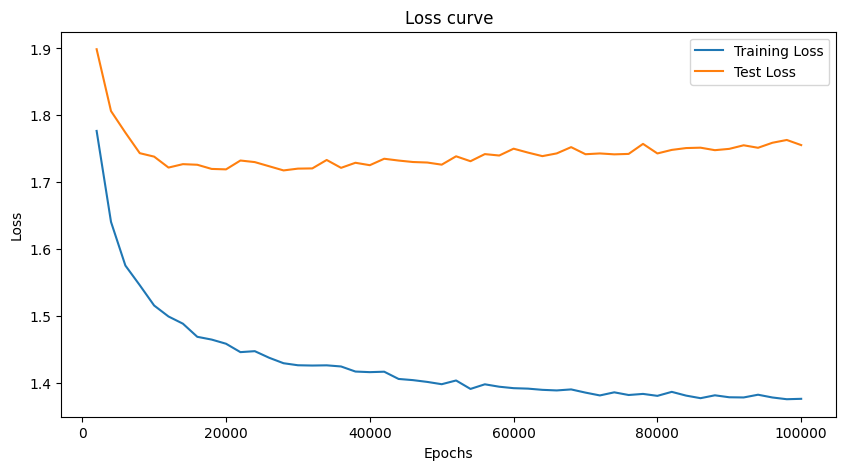

In [10]:
import matplotlib.pyplot as plt

### Visualize loss progression ###
plt.figure(figsize=(10, 5))
plt.plot(epoch_count, train_loss_values, label="Training Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [39]:
### Use model ###

def evaluate(model, start='\n', length=1000, temperature=0.8):
    model.eval()

    hidden = model.init_hidden()
    prime_input = torch.tensor([[char_to_num[c] for c in start]])
    predicted = start

    # Build up hidden state
    for i in range(len(start) - 1):
        with torch.inference_mode():
            _, hidden = model(prime_input[i].to(device), hidden)

    # Generate new sequence
    input = prime_input[-1]
    for i in range(length):
        with torch.inference_mode():
            output, hidden = model(input.to(device), hidden)

        probs = F.softmax(output.detach(), dim=1)
        ix = torch.multinomial(probs, num_samples=1)[0]

        char = num_to_char[ix.item()]
        predicted += char
        input = ix.clone().detach()
    
    return predicted
    
print(evaluate(model))


All pilet,
From Richard;
Lest thou a maid,
That as moleot'sts are run.

RIVERS:
Grand the shows?

CATESBY:
Ha! more swords cannot be king; be gone, madam.

AUFIDIUS:
I am a son, yet knows,
Even shop Coriolanus
And make a power in them, and in a highness are as from their foul that knows moving word, their fore of York and fresh dangerous good.

PAULINA:
I'll be kith;
She
Then both the govoong
That ever me as his pripher him that made your master and then he had story is it, I have earth.
Murdemit how alars and times down: make thee, as I brought
In this with thee,--that they capes on this, why dost thou shall never lost to be warrant
In for again canifly what you must fall elevingh is most sain!
The mean. This motherdonour traitor of his trade.

LUCIO:
Ah, Plearer.

BRUTUS:
Boen is well.

BUSHY:
Them come, men he unague being blows,
His ears,
Whererhow,
Intended
mean himself round both.

LADY ANNE:
Wndw we this, which vaulo, gamely!

NORTHUMBERLAND:
That our neighbour.

FLORIZEL:
O wh